# 1.Background Story

In today's competitive business environment, organizations strive to attract and retain skilled employees by offering fair and competitive compensation. Salary decisions are influenced by factors such as education, work experience, job role, department, location, and employee skills. Manual salary estimation can lead to inconsistencies, pay inequality, and inefficient workforce planning. Using Machine Learning, organizations can predict employee salaries more accurately, enabling data-driven compensation decisions, better budgeting, and improved talent management.

# 2.Problem Statement

Many organizations face challenges in determining appropriate salaries for new hires and existing employees. Inconsistent salary decisions may result in employee dissatisfaction, increased attrition, and budgeting issues. Therefore, there is a need for an intelligent system that can estimate employee salaries based on relevant employee and job-related information.

# 3.Objective

Develop a Machine Learning solution that predicts employee salaries accurately using historical employee data. The solution will help HR professionals make informed compensation decisions, improve salary planning, maintain pay equity, and optimize workforce budgeting.

4. Project Title

Employee Salary Prediction using Machine Learning

5. Domain

Human Resources (HR) / People Analytics

6. Machine Learning Task

Regression

7. Target Variable

Salary

# Import Necessary Libraries

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,StandardScaler

from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import joblib

# Data Collection

In [7]:
data=pd.read_csv(r"C:\Users\mainu\Desktop\Employee Salary Prediction\Employers_data.csv")
df=data.copy()
print(df.head())
print(df.tail())

   Employee_ID            Name  Age  Gender   Department  Job_Title  \
0            1    Merle Ingram   24  Female  Engineering   Engineer   
1            2      John Mayes   56    Male        Sales  Executive   
2            3    Carlos Wille   21    Male  Engineering     Intern   
3            4  Michael Bryant   30    Male      Finance    Analyst   
4            5   Paula Douglas   25  Female           HR    Analyst   

   Experience_Years Education_Level  Location  Salary  
0                 1          Master    Austin   90000  
1                33          Master   Seattle  195000  
2                 1        Bachelor  New York   35000  
3                 9        Bachelor  New York   75000  
4                 2          Master   Seattle   70000  
      Employee_ID            Name  Age  Gender   Department  Job_Title  \
9995         9996   Thomas Rossin   51    Male        Sales  Executive   
9996         9997   Christie King   36  Female        Sales  Executive   
9997         99

Observation:

- The dataset was loaded successfully.
- The first and last five records were displayed.
- The data contains employee details along with the target variable **Salary**.
- The dataset is ready for further analysis.

# Data Understanding

In [11]:
print(df.shape)
print(df.info())
print(df.columns)
print(df.dtypes)
print(df.describe())
print(df.describe(include=object))

(10000, 10)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Employee_ID       10000 non-null  int64
 1   Name              10000 non-null  str  
 2   Age               10000 non-null  int64
 3   Gender            10000 non-null  str  
 4   Department        10000 non-null  str  
 5   Job_Title         10000 non-null  str  
 6   Experience_Years  10000 non-null  int64
 7   Education_Level   10000 non-null  str  
 8   Location          10000 non-null  str  
 9   Salary            10000 non-null  int64
dtypes: int64(4), str(6)
memory usage: 1.2 MB
None
Index(['Employee_ID', 'Name', 'Age', 'Gender', 'Department', 'Job_Title',
       'Experience_Years', 'Education_Level', 'Location', 'Salary'],
      dtype='str')
Employee_ID         int64
Name                  str
Age                 int64
Gender                str
Department            str
Job_Titl

Shape

Observation:

- The dataset contains 10,000 rows and 10 columns.

Dataset Information (info())

Observation:

- The dataset contains 4 numerical and 6 categorical features.
- All columns have 10,000 non-null values, indicating no missing values.
- The dataset occupies approximately 1.2 MB of memory.

Columns

Observation:

- The dataset includes employee demographic, job-related, and salary information.

Data Types

Observation:

- Numerical columns are stored as int64.
- Categorical columns are stored as string (str).

Statistical Summary (describe())

Observation:

- Numerical features such as Age, Experience_Years, and Salary show a reasonable distribution and will be analyzed further during EDA.

Categorical Summary (describe(include='object'))

Observation:

- The dataset contains Gender, Department, Job_Title, Education_Level, and Location as categorical features.
- These features have multiple categories and will require encoding before model training.


# Data Quality Checking

In [12]:
df.isnull().sum()

Employee_ID         0
Name                0
Age                 0
Gender              0
Department          0
Job_Title           0
Experience_Years    0
Education_Level     0
Location            0
Salary              0
dtype: int64

- No missing found in the dataset
- No need of handling missing values 

In [14]:
df.duplicated().sum()

np.int64(0)

- No duplicates found in the dataset
- Therefore no treatment is needed for duplicates.

# Feature Identification

In [17]:
num_col=df.select_dtypes(include=['int64'])
print(num_col)

      Employee_ID  Age  Experience_Years  Salary
0               1   24                 1   90000
1               2   56                33  195000
2               3   21                 1   35000
3               4   30                 9   75000
4               5   25                 2   70000
...           ...  ...               ...     ...
9995         9996   51                28  185000
9996         9997   36                 9  165000
9997         9998   57                30  200000
9998         9999   37                14  135000
9999        10000   25                 4   70000

[10000 rows x 4 columns]


- The dataset contains 4 numerical features:

Employee_ID,
Age,
Experience_Years,
Salary

In [18]:
cat_col=df.select_dtypes(include=['object'])
print(cat_col)

                Name  Gender   Department  Job_Title Education_Level  \
0       Merle Ingram  Female  Engineering   Engineer          Master   
1         John Mayes    Male        Sales  Executive          Master   
2       Carlos Wille    Male  Engineering     Intern        Bachelor   
3     Michael Bryant    Male      Finance    Analyst        Bachelor   
4      Paula Douglas  Female           HR    Analyst          Master   
...              ...     ...          ...        ...             ...   
9995   Thomas Rossin    Male        Sales  Executive          Master   
9996   Christie King  Female        Sales  Executive             PhD   
9997   Alfred Keller    Male        Sales  Executive             PhD   
9998  Margaret Gomez  Female  Engineering    Manager          Master   
9999   Joan Sorensen  Female        Sales    Analyst        Bachelor   

           Location  
0            Austin  
1           Seattle  
2          New York  
3          New York  
4           Seattle  
...

- The dataset contains 6 categorical features:

Name,
Gender,
Department,
Job_Title,
Education_Level,
Location

In [19]:
y=df['Salary']
print(y)

0        90000
1       195000
2        35000
3        75000
4        70000
         ...  
9995    185000
9996    165000
9997    200000
9998    135000
9999     70000
Name: Salary, Length: 10000, dtype: int64


- **Salary** is the target variable to be predicted.

# Drop Unnecessary columns

In [28]:
# Drop Unnecessary Columns

df = df.drop(columns=['Employee_ID', 'Name'])

# Verify the Updated Dataset
print(df.head())

# Check the Updated Shape
print("Updated Shape:", df.shape)

   Age  Gender   Department  Job_Title  Experience_Years Education_Level  \
0   24  Female  Engineering   Engineer                 1          Master   
1   56    Male        Sales  Executive                33          Master   
2   21    Male  Engineering     Intern                 1        Bachelor   
3   30    Male      Finance    Analyst                 9        Bachelor   
4   25  Female           HR    Analyst                 2          Master   

   Location  Salary  
0    Austin   90000  
1   Seattle  195000  
2  New York   35000  
3  New York   75000  
4   Seattle   70000  
Updated Shape: (10000, 8)


Observation:
- Employee_ID and Name were removed as they are unique identifier columns and do not contribute to salary prediction.
- The dataset now contains 10,000 rows and 8 useful features, making it suitable for further analysis.

In [31]:
# Numerical Features
num_col = df.select_dtypes(include=['int64', 'float64']).columns
print("Numerical Features:")
print(num_col)

# Categorical Features
cat_col = df.select_dtypes(include=['object']).columns
print("\nCategorical Features:")
print(cat_col)

Numerical Features:
Index(['Age', 'Experience_Years', 'Salary'], dtype='str')

Categorical Features:
Index(['Gender', 'Department', 'Job_Title', 'Education_Level', 'Location'], dtype='str')


In [32]:
# Target Variable
target = 'Salary'
print("Target Variable:", target)

Target Variable: Salary


Observation:
- The dataset contains 3 numerical features: Age, Experience_Years, and Salary.
- The dataset contains 5 categorical features: Gender, Department, Job_Title, Education_Level, and Location.
- **Salary** is the target variable.

# Univariate Analysis

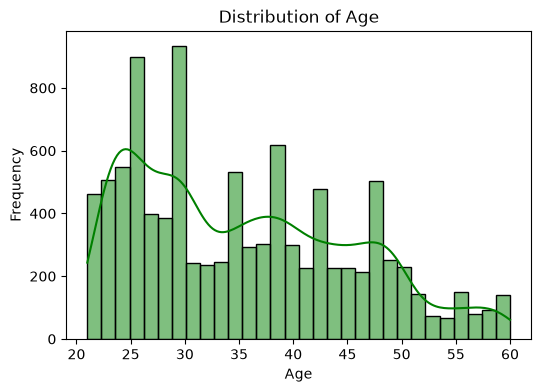

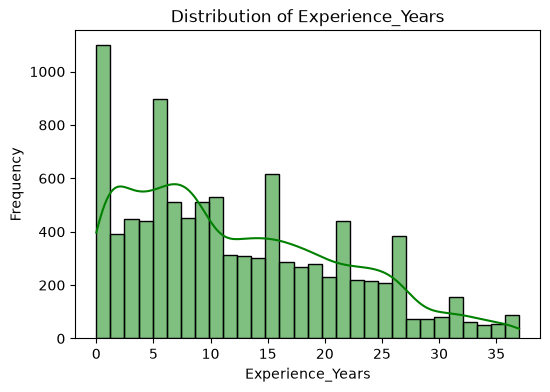

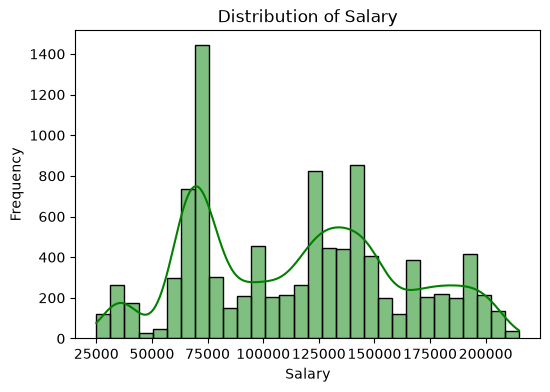

In [33]:
# Histogram for Numerical Features

for col in num_col:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=30, kde=True, color='green')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

Observation:
- Age: Most employees are between 20 and 40 years.
- Experience_Years: Most employees have low to moderate experience, with fewer highly experienced employees.
- Salary: Salaries are distributed across multiple salary ranges, showing variation among employees.

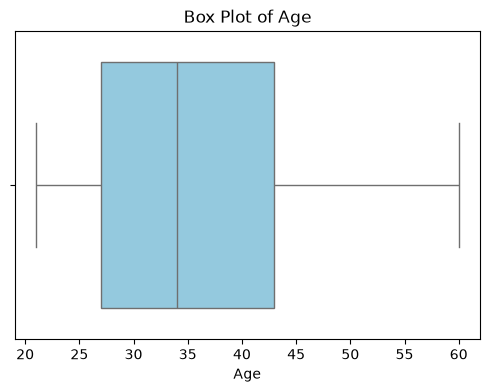

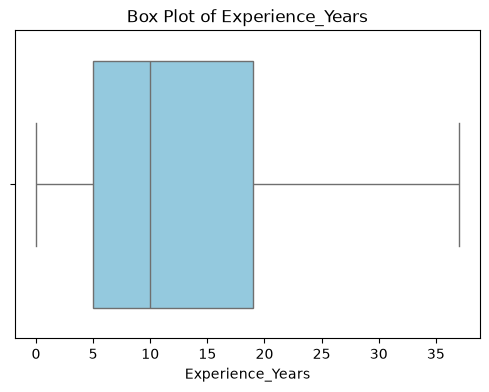

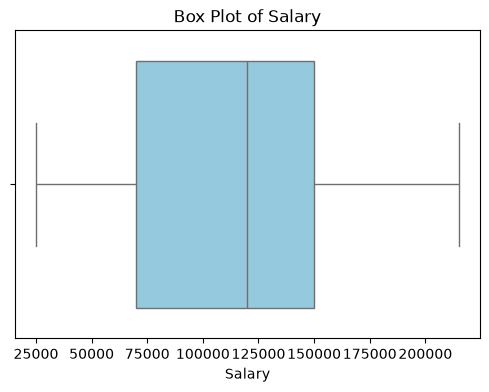

In [34]:
# Box Plot for Numerical Features

for col in num_col:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f"Box Plot of {col}")
    plt.xlabel(col)
    plt.show()

Observation:
- Age: No significant outliers are observed.
- Experience_Years: No significant outliers are observed.
- Salary: No significant outliers are observed.
- No outlier treatment is required.

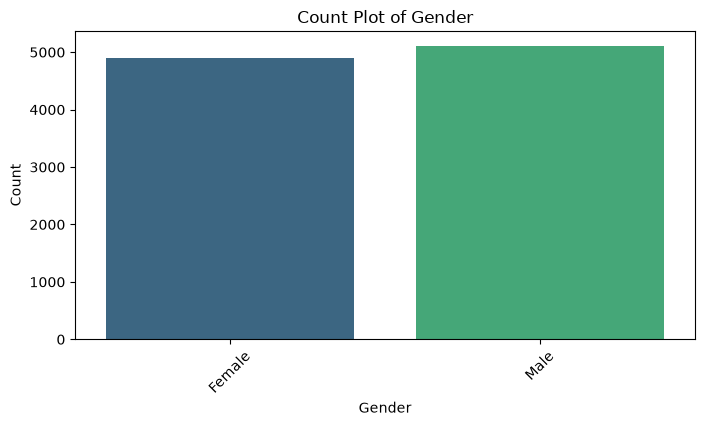

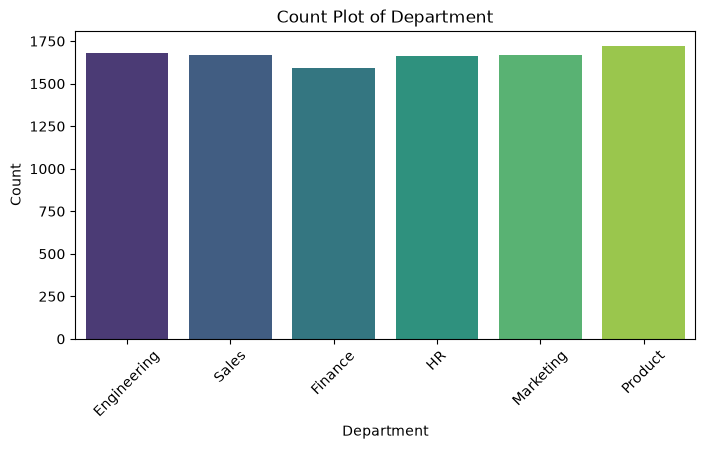

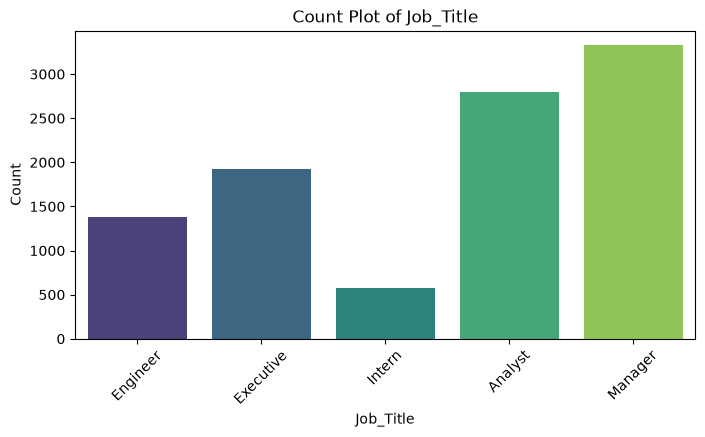

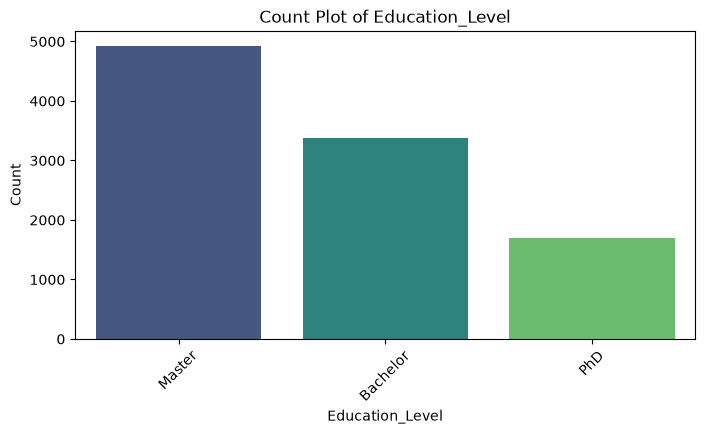

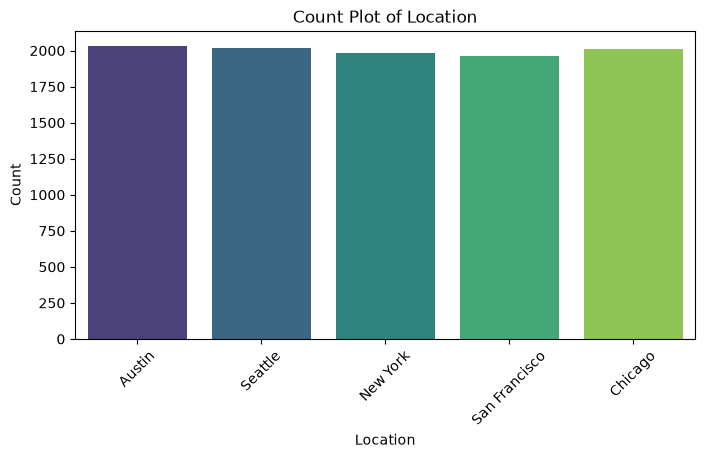

In [35]:
# Count Plot for Categorical Features

for col in cat_col:
    plt.figure(figsize=(8,4))
    sns.countplot(x=df[col], palette='viridis')
    plt.title(f"Count Plot of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

Observation:
- Gender: Male and female employees are almost equally distributed.
- Department: Employees are fairly distributed across all departments.
- Job Title: Manager is the most common role, while Intern is the least common.
- Education Level: Most employees have a Master's degree, followed by Bachelor's and PhD.
- Location: Employees are almost evenly distributed across all locations.

# Bivariate Analysis

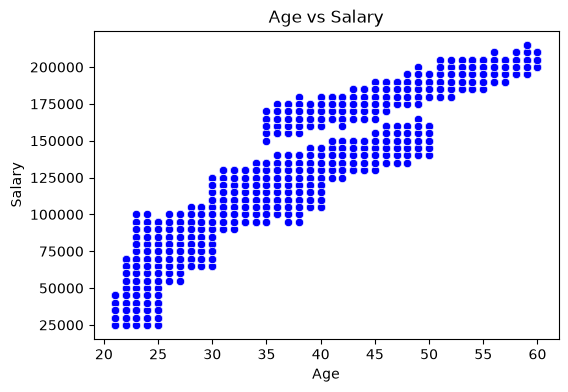

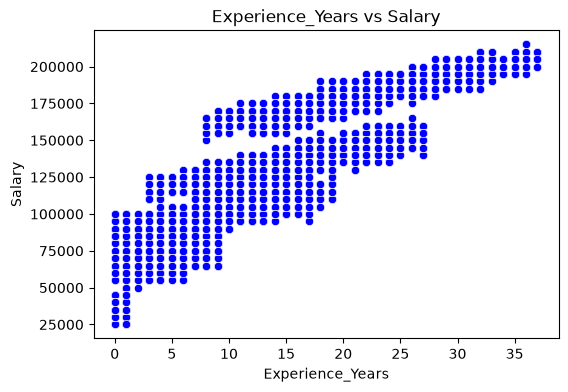

In [36]:
for col in num_col:
    if col != 'Salary':
        plt.figure(figsize=(6,4))
        sns.scatterplot(x=df[col], y=df['Salary'], color='blue')
        plt.title(f'{col} vs Salary')
        plt.xlabel(col)
        plt.ylabel('Salary')
        plt.show()

Observation:
- Age vs Salary: Salary generally increases as age increases, indicating a positive relationship.
- Experience_Years vs Salary: Salary increases with experience, showing a strong positive correlation between experience and salary.

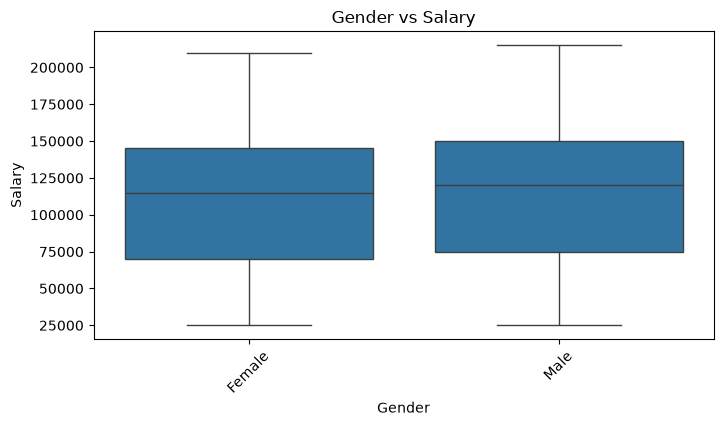

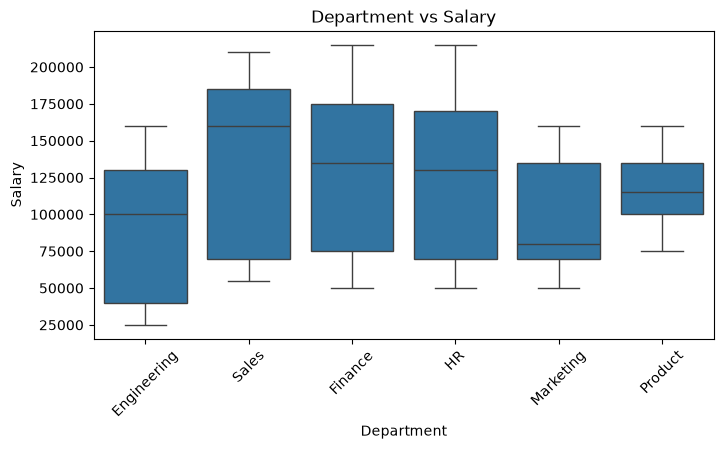

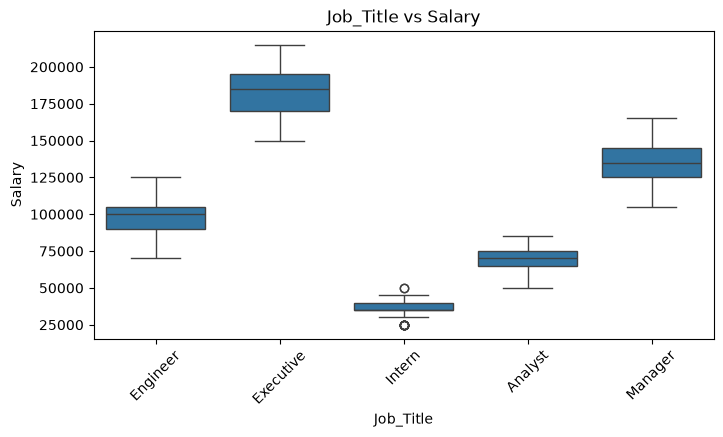

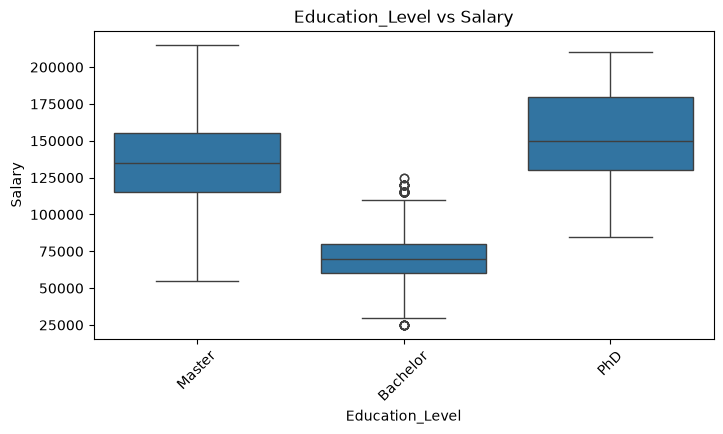

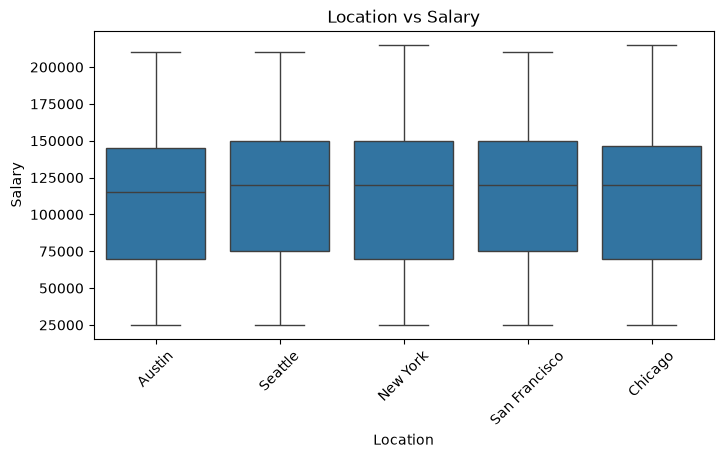

In [37]:
# Box Plot for Categorical Features vs Salary

for col in cat_col:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col], y=df['Salary'])
    plt.title(f'{col} vs Salary')
    plt.xlabel(col)
    plt.ylabel('Salary')
    plt.xticks(rotation=45)
    plt.show()

Observation:
- Gender vs Salary: Male and female employees have similar salary distributions.
- Department vs Salary: Salary varies across departments, with Sales showing a higher median salary than some other departments.
- Job_Title vs Salary: Executives have the highest salaries, while Interns have the lowest.
- Education_Level vs Salary: Employees with a PhD generally earn higher salaries than those with a Master's or Bachelor's degree.
- Location vs Salary: Salary distributions are similar across locations, with no major differences.

# Multivariate Analysis

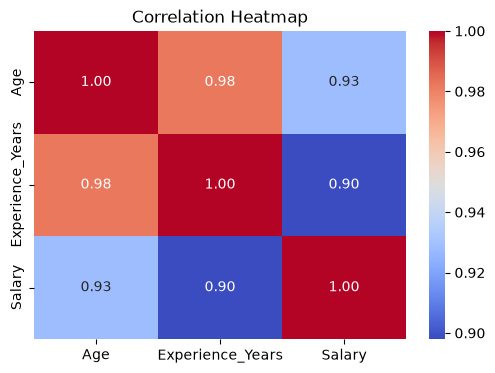

In [38]:
# Correlation Heatmap

plt.figure(figsize=(6,4))
sns.heatmap(df[num_col].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

Observation:
- Age and Experience_Years have a very strong positive correlation (0.98).
- Age has a strong positive correlation (0.93) with Salary.
- Experience_Years also has a strong positive correlation (0.90) with Salary.
- Overall, salary tends to increase as age and experience increase.

# Data Preprocessing

In [40]:
X = df.drop(columns='Salary')
y = df['Salary']

Observation:
- X contains all independent features.
- y contains the target variable Salar

In [42]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8000, 7)
(2000, 7)
(8000,)
(2000,)


Observation:
- Training set contains 8,000 records.
- Testing set contains 2,000 records.
- The dataset was successfully split in an 80:20 ratio for training and testing.

In [43]:
X_train.columns

Index(['Age', 'Gender', 'Department', 'Job_Title', 'Experience_Years',
       'Education_Level', 'Location'],
      dtype='str')

In [54]:
num_col = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_col = X_train.select_dtypes(include=['object']).columns
print(num_col)
print(cat_col)

Index(['Age', 'Experience_Years'], dtype='str')
Index(['Gender', 'Department', 'Job_Title', 'Education_Level', 'Location'], dtype='str')


Observation:
- The training data contains 2 numerical and 5 categorical features.
- These will be preprocessed separately using different pipelines

# Numerical Pipeline

In [55]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Categorical Pipeline

In [56]:
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(handle_unknown='ignore'))
])

Observation:
- Missing values in categorical features are replaced with the most frequent category.
- Categorical features are converted into numerical format using One-Hot Encoding.

# Create ColumnTransformer

In [57]:
preprocessor=ColumnTransformer([
    ('num',num_pipeline,num_col),
    ('cat',cat_pipeline,cat_col)
])

Observation:
- The ColumnTransformer successfully combines the numerical and categorical preprocessing pipelines.
- Numerical features will be imputed and scaled.
- Categorical features will be imputed and one-hot encoded.

# Create KNN Regressor Pipeline

In [58]:
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KNeighborsRegressor())
])

Observation:
- The KNN pipeline has been successfully created.
- The data will be preprocessed automatically before training the KNN Regressor.

# Define Hyperparameter Grid for KNN

In [59]:
knn_params = {
    'model__n_neighbors': [3, 5, 7, 9,11],
    'model__weights': ['uniform', 'distance'],
    'model__metric': ['euclidean', 'manhattan']
}

Observation:
- The hyperparameter grid is created to search for the optimal KNN parameters.
- Multiple combinations of neighbors, weights, and distance metrics will be evaluated.

In [60]:
# Create GridSearchCV for KNN
knn_grid = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

Observation:
- GridSearchCV is configured to identify the best KNN hyperparameters using 5-fold cross-validation and the R² evaluation metric.

In [61]:
# Fit the GridSearchCV Model
knn_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...Regressor())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__metric': ['euclidean', 'manhattan'], 'model__n_neighbors': [3, 5, ...], 'model__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbos

# Best Hyperparameters

In [62]:
print(knn_grid.best_params_)

{'model__metric': 'euclidean', 'model__n_neighbors': 5, 'model__weights': 'uniform'}


Observation:
- The optimal number of neighbors selected is 5.
- The Euclidean distance metric provides the best performance.
- Uniform weighting gives equal importance to all selected neighbors.

In [63]:
# Best Cross-Validation Score
print(knn_grid.best_score_)

0.9874383183907488


Observation:
- The best average R² score obtained during 5-fold cross-validation is 0.9874.
- This indicates that the tuned KNN model performs very well on the training data.

In [64]:
# Best Estimator
best_knn = knn_grid.best_estimator_

- The best KNN pipeline is stored in best_knn for prediction and evaluation.

In [65]:
# Predict on Test Data
y_pred = best_knn.predict(X_test)

- The trained KNN model predicts salary values for the test dataset.

# Model Evaluation

In [72]:
# Evaluation Metrics

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2_knn = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 4089.5
Mean Squared Error (MSE): 26697500.0
Root Mean Squared Error (RMSE): 5166.9623571301545
R² Score: 0.9911420580281134


Observation:
- The KNN Regressor achieved an R² score of 98.73%, indicating excellent predictive performance.
- The model's prediction error is low, demonstrating that it predicts employee salaries accurately.

# Decision Tree Regressor

In [68]:
# Decision Tree Pipeline

dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(random_state=42))
])

# Hyperparameter Grid

dt_params = {
    'model__criterion': ['squared_error', 'friedman_mse'],
    'model__max_depth': [3, 5, 7, 10, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

In [69]:
# GridSearchCV

dt_grid = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Fit the Model

dt_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__criterion': ['squared_error', 'friedman_mse'], 'model__max_depth': [3, 5, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0

Observation:

- The preprocessing pipeline and Decision Tree Regressor were successfully integrated into a single workflow.

In [70]:
# Best Hyperparameters

print("Best Hyperparameters:")
print(dt_grid.best_params_)

# Best Cross Validation Score

print("Best Cross Validation Score:")
print(dt_grid.best_score_)

# Best Estimator

best_dt = dt_grid.best_estimator_

# Prediction

y_pred_dt = best_dt.predict(X_test)

Best Hyperparameters:
{'model__criterion': 'squared_error', 'model__max_depth': 7, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10}
Best Cross Validation Score:
0.9907609341503296


Observation:
- GridSearchCV selected the optimal hyperparameters to improve the Decision Tree model's performance.
- The model achieved a cross-validation R² score of 0.9908, indicating excellent performance on the training data.

In [73]:
# Evaluation Metrics

mae = mean_absolute_error(y_test, y_pred_dt)
mse = mean_squared_error(y_test, y_pred_dt)
rmse = np.sqrt(mse)
r2_dt = r2_score(y_test, y_pred_dt)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 3453.984275832024
Mean Squared Error (MSE): 18669547.636988264
Root Mean Squared Error (RMSE): 4320.827193604052
R² Score: 0.9911420580281134


Observation:

- The Decision Tree Regressor achieved low prediction error and a high R² score (0.9911), indicating excellent predictive performance on the test dataset.

# Best Model

In [74]:
if r2_dt > r2_knn:
    best_model = best_dt
    print("Best Model: Decision Tree Regressor")
    print("R² Score:", r2_dt)
else:
    best_model = best_knn
    print("Best Model: KNN Regressor")
    print("R² Score:", r2_knn)

Best Model: Decision Tree Regressor
R² Score: 0.9911420580281134


# Final Model Conclusion

Observation:

- The Decision Tree Regressor achieved the highest R² score (0.9911) with lower prediction errors compared to the KNN Regressor (0.9873).
- Therefore, the Decision Tree Regressor was selected as the final model for deployment.

# Save the Best Model

In [75]:
# Save the Best Model

joblib.dump(best_model, 'best_model.pkl')

['best_model.pkl']

- The best-performing model was saved successfully for future predictions and deployment.

In [76]:
# Save the Preprocessor
joblib.dump(preprocessor, 'preprocessor.pkl')

['preprocessor.pkl']

Observation:
- The preprocessing pipeline was saved successfully to ensure the same preprocessing steps are applied during deployment.

In [77]:
# Verify Saved Files
import os

print(os.listdir())

['app.py', 'best_model.pkl', 'Employee Salary Prediction.ipynb', 'Employers_data.csv', 'preprocessor.pkl', 'requirements.txt', 'venv']


Observation:
- The trained model (best_model.pkl) and preprocessing pipeline (preprocessor.pkl) have been saved successfully.
- The project is now ready for Streamlit application development and deployment.